# Production Networks

**Prerequisites**

- Introduction to Graphs
- Weighted Graphs

**Outcomes**

- Recall the key concepts of spectral theory from Linear Algebra
- Desribe the key proprties of the Leintief family of production models
- Explain the difference between "in"-based centrality and "out"-based centrality
- Analyze the impact of sector specific shocks on other sectors of the US economy

**References**

- [QuantEcon Networks](https://networks.quantecon.org/) chapters 1-2  (especially section 1.2)

## Linear Algebra

- Linear algebra is the backbone of modern computational algorithms
    - Graphics
    - Statistics
    - Data analysis
    - Optimization
    - Machine Learning
- Workhorse for accelerated computing
  - GPUs work on matrices to efficiently parallellize common computations
  - Specialty hardware like the TPU (tensor processing unit) take this even further

### Building Blocks

- Vectors: arrays of numbers representing points in multi-dimensional space
- Matrices
    - Rectangular arrays that transform vectors
    - Also used to represent certain datasets/relationships: e.g. adjacency matrix in Graph Theory
- Tensors: higher dimensional collections of numbers that allow high-dimensional
    - Vectors are 1d tensors, matrices 2d tensors, etc.
    - Implemented in numpy as the `np.array` type

### Some Key Theories

1. Linear systems of equations
2. Inner product spaces (length, distance, and angles)
3. Eigenvalues and eigen vectors (spectral theory)

### Spectral Theory

- Let's dig into eigenvalues and eigenvectors
- Let $A \in \mathbb{R}^{n \times n}$
- A scalar $\lambda \in \mathbb{C}$ is an **eigenvalue** of $A$ if there exists a nonzero vector $e \in \mathbb{C}^n$ such that $A e = \lambda e$
- A vector $e$ satisfying this equality is called an **eigenvector** corresponding to the eigenvalue $\lambda$
- A vector $\epsilon$ sastifying $A ' \epsilon = \lambda \epsilon$ is a **left-eigenvector** of $A$

In [1]:
import numpy as np

In [2]:
A = np.array([
    [0, -1],
    [1, 0],
])
np.linalg.eigvals(A)

array([0.+1.j, 0.-1.j])

#### Definitions

- The set of all eigenvalues of $A$ is called the **spectrum** of $A$ and is written $\sigma(A)$
- The **spectral radius** of $A$ is written $r(A) \equiv \max \{ | \lambda | : \lambda \in \sigma(A) \}$
    - The spectral radius important when considering the convergence of a dynamic system driven by $A$
    - If $x_{t+1} = A x_t$ and $r(A)< 1$ then the sequence $\{x\}_t$ is finite and will converge
- Some facts (not proven here)
    - $A$ will have *at most* $n$ distinct eigenvalues
    - Eigenvectors are only unique to a scalar multiple: if $(\lambda, e)$ is an eigenpair, then so is $(\lambda, \alpha e)$ for any $\alpha \in \mathbb{R}, \alpha \ne 0$
- Sometimes a matrix will have a repeated eigenvalue (the same value works with multiple distinct eigenvectors)
- The **algebraic multiplicity** of an eigenvalue is the number of times it is repeated with distinct eigenvectors
- An eigenvalue with an algebraic multiplicity of one is called **simple**

#### Diagonalization

- A matrix $A \in \mathbb{R}^{n \times n}$ is diagonalizable if $A = PDP^{-1}$
    - $D = \text{diag}(\lambda_1, \dots, \lambda_n)$, $P$ is some invertible matrix
- The decomposition is called the **eigen decomposition** or **spectral decomposition** of $A$
- The asymptotic properties of $m \mapsto A^m$ are determined by $\sigma(A)$
    - Can be seen when $A$ is diagonalizable
    - If $A = P \text{diag}(\lambda) P^{-1} \Longrightarrow A^m = P \text{diag}(\lambda_i^m) P^{-1}$

### Example: Worker Dynamics

- Consider a continuum of workers (large number, not counted discretely)
- Workers can be in one of two states: (1) employed and (2) unemployed
- Each month workers are hired at a rate $\alpha$ and fired at a rate $\beta$
- We express these dynamics as a weighted directed graph with adjacency matrix:

$$P_w = \begin{bmatrix}1-\alpha & \alpha \\ \beta & 1-\beta \end{bmatrix} \; \alpha, \beta \in [0, 1]$$

- Row $1$ gives the probabilities of employment and unemployement for an employed worker
- Row $2$ gives the probabilities of employment and unemployement for an unemployed worker

#### Transitions

- Suppose we have a vector $x \in \Delta(2)$ (2 element simplex) representing current fraction of workers that are employed and unemployed
- Question... What matrix operation between $P_w$ and $x$ will give the fraction of workers that start next month as employed and unemployed?

In [3]:
alpha = 0.3
beta = 0.1

P = np.array([
    [1 - alpha, alpha],
    [beta, 1 - beta],
])
P

array([[0.7, 0.3],
       [0.1, 0.9]])

In [4]:
x = np.array([0.9, 0.1])

In [5]:
# TODO: simulate for many periods

In [6]:
# TODO: compare to largest left eigenvector

### Neumann Series Lemma

- We need one more linear alegbra result...
- If $A \in \mathbb{R}^{n \times n}$ and $r(A) < 1$, then $I-A$ is non-singular and $$(I-A)^{-1} = \sum_{m=0}^{\infty} A^m$$
- This is known as the Neumann series lemma

## Production Networks

- We will now study a family of economic models that allow us to analyze the economy as a collection of sectors
- These models were proposed by nobel prize winner Wassily Leontief in 1941 and are still commonly used today
- The key idea behind a Leontief model is the input-output table

### Input-output tables

- Firms (companies) are categorized into $n$ distinct sectors
- Firms use materials produced by other sectors as part of their production process
- The relationship of flows of *value* are organized into an input/output table

| | sector 1 | sector 2 | sector 3|
|-| -------- | -------- | ------- | 
| sector 1 | $a_{11}$ | $a_{12}$ | $a_{13}$ |
| sector 2 | $a_{21}$ | $a_{22}$ | $a_{23}$ |
| sector 3 | $a_{31}$ | $a_{32}$ | $a_{33}$ |

- $a_{ij}$ is called an **input-output coefficient** and is equal to:

$$a_{ij} = \frac{\text{value of sector j inputs purchased from sector i}}{\text{total sales of sector j}}$$

- If $a_{ij}$ is large, sector $i$ is an important **supplier** of intermediate goods to sector $j$
- The sum of column $j$ is the value of all inputs to sector $j$
- Row $i$ shows how intensively each sector uses good $i$ as an intermediate good
- The input output table can be directly used as the adjacency matrix for a weighted directed graph

### Input-output data

- In the United States, the Bureau of Economic Analysis is responsible for compiling input-output tables for sectors
- We'll be studying the [Input-Output Accounts Data](https://www.bea.gov/industry/input-output-accounts-data)
- The main set of tables we'll be using are called the `Make-Use` tables
- The `Make` table shows the value of final goods produced by each sector
    - Note this is predominately a diagonal matrix as each sector primarily produces and sells final goods within their sector
    - Sometimes a firm will have secondary outputs as part of their production process
    - "Which industries produce which commodities?"
- The `Use` tables show the intermediate and final use of commodities across sectors
    - "Who uses or consumes the commodities produced?" 

In [7]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import requests
from pathlib import Path
from dataclasses import dataclass, fields

In [8]:
def read_remote_csv(url):
    bn = Path(url).name
    if not Path(bn).exists():
        resp = requests.get(url)
        resp.raise_for_status()
        Path(bn).write_bytes(resp.content)
    return pd.read_csv(bn)


make_15 = read_remote_csv("https://compsosci-resources.s3.amazonaws.com/graph-theory-lectures/data/QE-networks/make_15.csv")
use_15 = read_remote_csv("https://compsosci-resources.s3.amazonaws.com/graph-theory-lectures/data/QE-networks/use_15.csv")
codes = read_remote_csv("https://compsosci-resources.s3.amazonaws.com/graph-theory-lectures/data/QE-networks/codes.csv")

### Example: US 15 sector data

![Input-Output Graph](https://compsosci-resources.s3.amazonaws.com/graph-theory-lectures/images/QE-networks/15-sector-graph.png)

- Color of nodes is according to their hub-based eigenvector centrality (see below)
- Size of nodes is according to their total outputs (make table)
- Thickness of edges is according to amount of goods
- Represent $a_{ij}$ and point from sector creating the intermediate good (sector $i$) to sector  using intermediate good (sector $j$)

#### Eigenvector Centrality

- The node size above shows the hub-based eigenvector centrality
- This is equal to the dominant eigenvector of the adjacency matrix (eigenvector associated with largest eigenvalue)
- This measure of centrality measures the influence of a node in a network
    - When computing this statistic for a node `N`, the value will be higher if it is connected to other "influential" nodes
    - https://youtu.be/LYyZqlyDEL4?si=x2kYhe3phZxQtQvV&t=202

#### Example

- Let's compute the eigenvector centrality for the data in the image above
- I have some code to import the make/use files into a helpful class
- We'll see what all the fields are as we progress through the lecture

In [9]:
@dataclass
class SectorData:
    Z: np.ndarray
    X: np.ndarray
    A: np.ndarray
    F: np.ndarray
    Z_df: pd.DataFrame
    names: np.ndarray
    codes: np.ndarray
    N: int
    G: nx.DiGraph


CODES = dict(zip(codes["name"], codes["code"]))


def eigenvector_centrality(G):
    # dominant (right) eigenvector of the adjacency matrix -- this is the
    # "hub-based" eigenvector centrality described above
    A = nx.to_numpy_array(G)
    eigvals, eigvecs = np.linalg.eig(A)
    idx = np.argmax(eigvals.real)
    vec = np.abs(eigvecs[:, idx].real)
    return vec / np.linalg.norm(vec)


def load_sector(N):
    # read csv
    df = pd.read_csv(f"use_{N}.csv")

    # replace `---` with `0`
    sector_cols = list(df.columns[1:N + 1])
    df[sector_cols] = df[sector_cols].replace("---", "0")

    # convert to int
    df[sector_cols] = df[sector_cols].astype(int)

    # first column is industry name, next columns are sector values
    # first N rows are values
    Z = df.loc[: N - 1, sector_cols].to_numpy()
    names = df.loc[: N - 1, df.columns[0]].to_numpy()
    sector_codes = np.array([CODES[n] for n in names])

    # total industry outputs come from the `make_N.csv` file
    make_df = pd.read_csv(f"make_{N}.csv")
    X = make_df.loc[: N - 1, "Total Industry Output"].to_numpy()

    # value of sector j's inputs purchased from i / sales of `j`
    # or ...
    A = Z / X[np.newaxis, :]

    F = Z / X[:, np.newaxis]

    # make copy of A where small values are set to zero to make plotting clearer
    A_copy = A.copy()
    A_copy[A <= 0.01] = 0
    G = nx.from_numpy_array(A_copy, create_using=nx.DiGraph)

    return SectorData(Z, X, A, F, df, names, sector_codes, N, G)

In [10]:
data15 = load_sector(15)

In [11]:
lambda15 = eigenvector_centrality(data15.G)

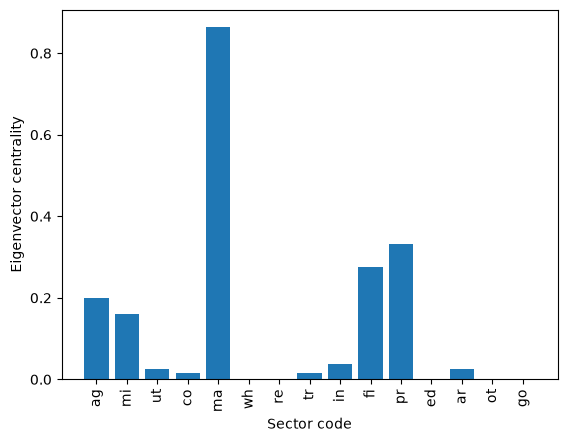

In [12]:
fig, ax = plt.subplots()
ax.bar([str(c) for c in data15.codes], lambda15)
ax.set_xlabel("Sector code")
ax.set_ylabel("Eigenvector centrality")
plt.xticks(rotation=90)
plt.show()

### Accounting

- Let...
    - $d_i$ be the final consumer demand for good $i$
    - $x_i$ be total sales of sector $i$
    - $z_{ij}$ be inter-industry sales from sector $i$ to sector $j$
- For accounts to add up we must have $$x_i = \sum_{j=1}^n z_{ij} + d_i$$
- Notice that $$\frac{z_{ij}}{x_j} = a_{ij} = \text{dollar value of inputs from $i$ per dollar output from $j$}$$
- This means $$x_i = \sum_{j=1} a_{ij} x_j + d_i$$
- Which can be written $x = Ax + d$

### Equilibrium

- An equilibrium in a Leonteif model with input-output coefficient matrix $A$ and a vector $d \in \mathbb{R}^n$ of final consumer demands for each sector is a vector $x$ for sector-specific output such that $x = Ax + d$ is satisfied
    - Note that $d$ and $A$ are treated as given
- To find this vector requires that we trace the impact of final demand on the intermediate linkages through $A$
- Example:

![Simple production network](https://compsosci-resources.s3.amazonaws.com/graph-theory-lectures/images/QE-networks/simple-production-network.png)

- Example
    - Suppose $d_3 \uparrow$
    - Will cause $3$ to consume more from its suppliers ($2$ and $4$)
    - Which will cause 2 to demand more from $1$
    - Which will cause $1$ to demand more from $2$ and $4$
    - ... and so on
- Computing an equilibrium is not entirely straight forward...

### Computing an Equilibrium

- Define $v_j \equiv x_j - \sum_{i=1}^n z_{ij}$ as the value added by sector $j$
- **Assumption**: The input-output adjacency matrix $A$ satisfies $$\eta_j \equiv \sum_{i=1}^n a_{ij} < 1 \; \forall j \in [n]$$
    - This holds whenever $v_j > 0 \forall j$
- When this assumption holds, for each $d \ge 0$ there is a unique, nonnegative output solution given by $$x^* = Ld \qquad \text{where } L \equiv (I-A)^{-1}$$
- The matrix $L$ is called the Leontief inverse associated with the coefficient matrix $A$

In [13]:
np.random.seed(6318)

L15 = np.linalg.inv(np.eye(15) - data15.A)

# propose a demand vector where each element is between [100, 600]
d = np.random.rand(15) * 500 + 100

L15 @ d

array([ 500.39460482,  565.50947751,  335.90852099,  365.35132967,
       1149.75242958,  201.93713081,  220.9301434 ,  597.48531726,
        456.91802938, 1204.63303233,  823.58490164,  459.0036682 ,
        296.67659945,  291.51130121,  352.68341994])

**Question**

We don't have a field for `d` in our `SectorData` class.

How could we compute/derive `d` given the fields we do have?

In [14]:
[f.name for f in fields(SectorData)]

['Z', 'X', 'A', 'F', 'Z_df', 'names', 'codes', 'N', 'G']

### Demand Shocks

- A common form of economic analysis is to consider the impact of external "shocks"
- Often, these are modeled as a one time change in the value of a variable
- Let's consider a demand shock of size $\Delta d$ such that demand moves from $d_0$ to $d_1 = \Delta d + d_0$
- The equilibrium vector shifts from $x_0 = L d_0$ to $x_1 = L d_1$
- Define $\Delta x = L (d_1 - d_0) = L \delta d$

### NSL

- We will further assume that $r(A)<1$ so that we can write the expression for $\Delta x$ as an infinite sum using the Neumann Series Lemma: $$\Delta x = \Delta d + A (\Delta d) + A^2 (\Delta d) + \cdots$$
    1. $\Delta d$ is the initial response in each sector,
    2. $A (\Delta d)$ is the response generated by the first round of backward linkages,
    3. $A^2 (\Delta d)$ is the response generated by the second round, and so on.
- The total response is the sum of the responses at each round
- The typical element $l_{ij}$ of $L = \sum_{m=0}^{\infty} A^m$ shows total impact on sector *i* of a unit change in the demand for good $j$

In [15]:
L15

array([[1.29184227e+00, 1.39760408e-02, 7.58555660e-03, 3.25231871e-02,
        7.95982148e-02, 8.58697937e-03, 1.10631586e-02, 1.28683072e-02,
        9.35271923e-03, 3.72477945e-03, 6.22659831e-03, 8.23600808e-03,
        2.13530414e-02, 8.17460302e-03, 1.92996197e-02],
       [2.98014801e-02, 1.14899239e+00, 9.18544739e-02, 4.96752855e-02,
        8.30716931e-02, 9.19916251e-03, 1.13317555e-02, 1.52884924e-02,
        1.16939575e-02, 6.37677341e-03, 6.83799499e-03, 9.41642141e-03,
        1.46944326e-02, 9.90946745e-03, 3.00173115e-02],
       [1.72817832e-02, 2.33040667e-02, 1.06272853e+00, 1.10804848e-02,
        1.41907848e-02, 1.87813230e-02, 3.67383349e-02, 2.45676061e-02,
        1.19409070e-02, 2.68271944e-02, 8.64009734e-03, 1.19933518e-02,
        3.16325116e-02, 9.65223136e-03, 1.83746364e-02],
       [7.01510333e-03, 8.26026364e-03, 1.35492365e-02, 1.00303986e+00,
        4.01568337e-03, 6.05963341e-03, 9.04230204e-03, 1.10085632e-02,
        5.70300082e-03, 2.96841960e-0

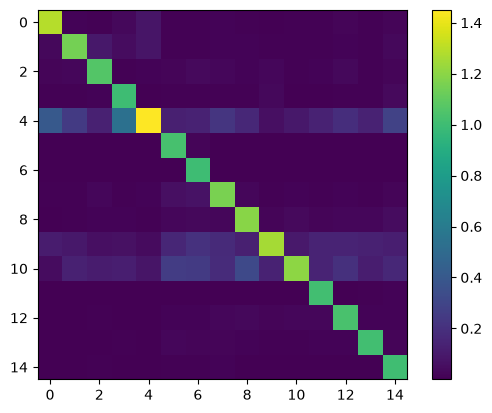

In [16]:
fig, ax = plt.subplots()
im = ax.imshow(L15, cmap="viridis")
fig.colorbar(im, ax=ax)
plt.show()